In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import json, os, re, math, copy

from collections import Counter, defaultdict

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from transformers import BertTokenizer, BertModel, BertForTokenClassification
from transformers import BertConfig

/home/oncreative/.local/lib/python3.10/site-packages/librosa/util/files.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2026-03-12 09:30:59.121767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773275459.140197 3775075 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773275459.146276 3775075 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773275459.160918 3775075 computation_placer.cc:177] compu

In [ ]:
ner_sentences = [
    # 문장 1
    [("이순신", "B-PER"), ("장군은", "O"), ("서울에서", "B-LOC"), ("태어났다", "O")],
    # 문장 2
    [("삼성전자는", "B-ORG"), ("수원에", "B-LOC"), ("본사를", "O"), ("두고", "O"), ("있다", "O")],
    # 문장 3
    [("김연아", "B-PER"), ("선수는", "O"), ("평창에서", "B-LOC"), ("은퇴했다", "O")],
    # 문장 4
    [("네이버는", "B-ORG"), ("한국의", "O"), ("대표적인", "O"), ("IT", "O"), ("기업이다", "O")],
    # 문장 5
    [("세종대왕은", "B-PER"), ("한글을", "O"), ("창제하였다", "O")],
    # 문장 6
    [("카카오는", "B-ORG"), ("제주도에", "B-LOC"), ("데이터센터를", "O"), ("건설했다", "O")],
    # 문장 7
    [("박지성", "B-PER"), ("선수는", "O"), ("맨체스터에서", "B-LOC"), ("뛰었다", "O")],
    # 문장 8
    [("현대자동차", "B-ORG"), ("울산", "B-LOC"), ("공장은", "O"), ("규모가", "O"), ("크다", "O")],
    # 문장 9
    [("유관순", "B-PER"), ("열사는", "O"), ("천안", "B-LOC"), ("출신이다", "O")],
    # 문장 10
    [("SK하이닉스는", "B-ORG"), ("이천에", "B-LOC"), ("위치한", "O"), ("반도체", "O"), ("회사다", "O")],
    # 문장 11
    [("손흥민", "B-PER"), ("선수는", "O"), ("런던에서", "B-LOC"), ("활약하고", "O"), ("있다", "O")],
    # 문장 12
    [("LG전자는", "B-ORG"), ("서울", "B-LOC"), ("여의도에", "O"), ("본사가", "O"), ("있다", "O")],
    # 문장 13
    [("정약용은", "B-PER"), ("남양주에서", "B-LOC"), ("유배생활을", "O"), ("했다", "O")],
    # 문장 14
    [("포스코는", "B-ORG"), ("포항", "B-LOC"), ("제철소를", "O"), ("운영한다", "O")],
    # 문장 15
    [("봉준호", "B-PER"), ("감독은", "O"), ("대구", "B-LOC"), ("출신이다", "O")],
]

In [ ]:
tag_list = ["O", "B-PER", "I-PER", "B-LOC", "I-LOC", "B-ORG", "I-ORG"]
tag2id = {tag: i for i, tag in enumerate(tag_list)}
id2tag = {i : tag for tag, i in tag2id.items()}

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

In [ ]:
tokenizer.vocab_size

119547

In [ ]:
sample_words = ["이순신", "장군은", "서울에서"]
for word in sample_words:
    tokens = tokenizer.tokenize(word)
    print(f" {word} -> {tokens}")

 이순신 -> ['이', '##순', '##신']
 장군은 -> ['장', '##군은']
 서울에서 -> ['서울', '##에서']


In [ ]:
def align_labels_with_tokens(words, word_labels, tokenizer, max_length=128):
    word_ids = []
    tokens_per_word = []
    for word_idx, word in enumerate(words):
        sub_tokens = tokenizer.tokenize(word)
        if not sub_tokens:
            sub_tokens = [tokenizer.unk_token]
        tokens_per_word.append(sub_tokens)
        word_ids.extend([word_idx] * len(sub_tokens))

    all_tokens = [tokenizer.cls_token] + [t for st in tokens_per_word for t in st] + [tokenizer.sep_token]
    word_ids_full = [None] + word_ids + [None]

    if len(all_tokens) > max_length:
        all_tokens = all_tokens[:max_length - 1] + [tokenizer.sep_token]
        word_ids_full = word_ids_full[:max_length -1] + [None]

    input_ids = tokenizer.convert_tokens_to_ids(all_tokens)
    attention_mask = [1] * len(input_ids)

    pad_len = max_length - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * pad_len
    attention_mask += [0] * pad_len
    word_ids_full += [None] * pad_len

    aligned_labels = []
    previous_word_id = None
    for word_id in word_ids_full:
        if word_id is None:
            aligned_labels.append(-100)
        elif word_id != previous_word_id:
            aligned_labels.append(word_labels[word_id])
        else:
            aligned_labels.append(-100)
        previous_word_id = word_id

    return (torch.tensor(input_ids, dtype=torch.long), torch.tensor(attention_mask, dtype=torch.long), torch.tensor(aligned_labels, dtype=torch.long))

In [ ]:
test_words = [w for w, _ in ner_sentences[0]]
test_words

['이순신', '장군은', '서울에서', '태어났다']

In [ ]:
test_labels = [tag2id[t] for _, t in ner_sentences[0]]
test_labels

[1, 0, 3, 0]

In [ ]:
input_ids, attention_mask, alinged_labels = align_labels_with_tokens(test_words, test_labels, tokenizer, max_length=32)

In [ ]:
input_ids

tensor([   101,   9638, 119064,  25387,   9657,  70605,  48253,  11489,  88921,
           102,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0])

In [ ]:
# attention_mask

In [ ]:
alinged_labels

tensor([-100,    1, -100, -100,    0, -100,    3, -100,    0, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100])

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(input_ids)

for tok , lab in zip(tokens, alinged_labels.tolist()):
    if tok == '[PAD]':
        break
    lab_str = id2tag[lab] if lab != -100 else '(-100)'
    print(f"{tok} {lab_str}")

[CLS] (-100)
이 B-PER
##순 (-100)
##신 (-100)
장 O
##군은 (-100)
서울 B-LOC
##에서 (-100)
태어났다 O
[SEP] (-100)


In [ ]:
MAX_LEN = 64

class NERDataset(torch.utils.data.Dataset):
    def __init__(self, sentences, tag2id, tokenizer, max_length=64):
        self.samples = []
        for sent in sentences:
            words = [w for w, _ in sent]
            labels = [tag2id[t] for _, t in sent]
            input_ids, attn_mask, aligned = align_labels_with_tokens(words, labels, tokenizer, max_length)
            self.samples.append((input_ids, attn_mask, aligned))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [ ]:
train_sents = ner_sentences[:12]
test_sents = ner_sentences[12:]

train_dataset = NERDataset(train_sents, tag2id, tokenizer, MAX_LEN)
test_dataset = NERDataset(test_sents, tag2id, tokenizer, MAX_LEN)

In [ ]:
for i in range(10):
    a, b, c = train_dataset.__getitem__(i)
    print(a.shape, b.shape, c.shape)

torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64]) torch.Size([64])


In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)


In [ ]:
NUM_LABELS = len(tag_list)

In [ ]:
tag_list

['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG']

In [ ]:
model_ner = BertForTokenClassification.from_pretrained('bert-base-multilingual-cased', num_labels = NUM_LABELS)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model_ner =  model_ner.to(DEVICE)

In [ ]:
model_ner.config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformer

In [ ]:
total_params = sum(p.numel() for p in model_ner.parameters())
total_params

177268231

In [ ]:
optimizer = torch.optim.AdamW(model_ner.parameters(), lr=3e-5, weight_decay=0.01)
NUM_EPOCHS = 10

model_ner.train()
loss_history= []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch in train_loader:
        # print(batch)
        input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]

        optimizer.zero_grad()
        outputs = model_ner(input_ids = input_ids, attention_mask = attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch+1) % 2 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} : loss : {avg_loss}")

Epoch 2/10 : loss : 0.02591821551322937
Epoch 4/10 : loss : 0.006961957551538944
Epoch 6/10 : loss : 0.004166304599493742
Epoch 8/10 : loss : 0.002517278849457701
Epoch 10/10 : loss : 0.0017420510994270444


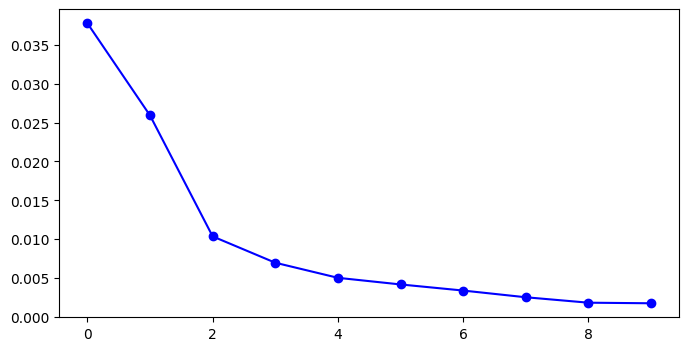

In [ ]:
plt.figure(figsize = (8, 4))
plt.plot(loss_history, 'b-o')
plt.show()

In [ ]:
# 100 * 1000

# log(100* 1000) = log100 + log1000

In [ ]:
from transformers import OpenAIGPTModel, OpenAIGPTLMHeadModel, OpenAIGPTTokenizer, GPT2LMHeadModel, GPT2Tokenizer

In [ ]:
tokenizer_gpt1 = OpenAIGPTTokenizer.from_pretrained('openai-gpt')
model_gpt1 = OpenAIGPTLMHeadModel.from_pretrained('openai-gpt')

In [ ]:
model_gpt1.to(DEVICE)

OpenAIGPTLMHeadModel(
  (transformer): OpenAIGPTModel(
    (tokens_embed): Embedding(40478, 768)
    (positions_embed): Embedding(512, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x Block(
        (attn): Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (lm_head): Linear(in_features=768, out_features=40478, bias=False)
)

In [ ]:
sum(p.numel() for p in model_gpt1.parameters())

116534784

In [ ]:
model_gpt1.config

OpenAIGPTConfig {
  "afn": "gelu",
  "architectures": [
    "OpenAIGPTLMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "openai-gpt",
  "n_ctx": 512,
  "n_embd": 768,
  "n_head": 12,
  "n_layer": 12,
  "n_positions": 512,
  "n_special": 0,
  "predict_special_tokens": true,
  "resid_pdrop": 0.1,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.56.0",
  "vocab_size": 40478
}

In [ ]:
# tokenizer_gpt1 = OpenAIGPTTokenizer.from_pretrained('openai-gpt')
# model_gpt1 = OpenAIGPTLMHeadModel.from_pretrained('openai-gpt')

In [ ]:
sentences = ["artificial intelligence is fun to study"]
tokens = tokenizer_gpt1.tokenize(sentences[0])
tokens

['artificial</w>',
 'intelligence</w>',
 'is</w>',
 'fun</w>',
 'to</w>',
 'study</w>']

In [ ]:
ids =  tokenizer_gpt1.encode(sentences[0])

In [ ]:
ids

[12823, 6804, 544, 2664, 485, 4174]

In [ ]:
prompt = "artificial intelligence is fun to study"
inputs = tokenizer_gpt1(prompt, return_tensors='pt').to(DEVICE)
inputs

{'input_ids': tensor([[12823,  6804,   544,  2664,   485,  4174]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [ ]:
ids = model_gpt1.generate(inputs.input_ids, max_length=32, temperature=0.3, top_k=30, do_sample=True)

In [ ]:
tokenizer_gpt1.decode(ids[0])

'artificial intelligence is fun to study , and i \'m sure you \'ll find a lot of interesting things to do . " \n " i \'m sure i will . "'

In [ ]:
def generate_text(prompt, max_length, temerature, top_k, do_sample):
    inputs = tokenizer_gpt1(prompt, return_tensors='pt').to(DEVICE)
    outputs = model_gpt1.generate(inputs.input_ids, max_length=max_length, temperature=temerature, top_k=top_k, do_sample=do_sample)

    return tokenizer_gpt1.decode(outputs[0])